Text(0.5, 1.0, 'face')

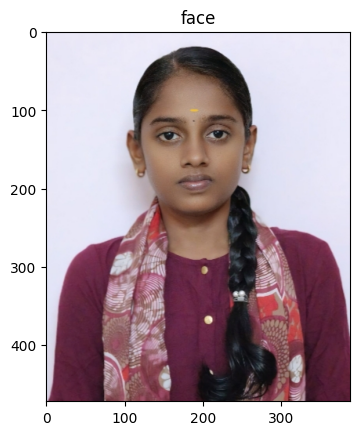

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
faceimage=cv2.imread("C:\\Users\\priya\\Downloads\\dipt\\my photo.jpg")
plt.imshow(faceimage[:,:,::-1]);plt.title("face")

Text(0.5, 1.0, 'GLASSPNG')

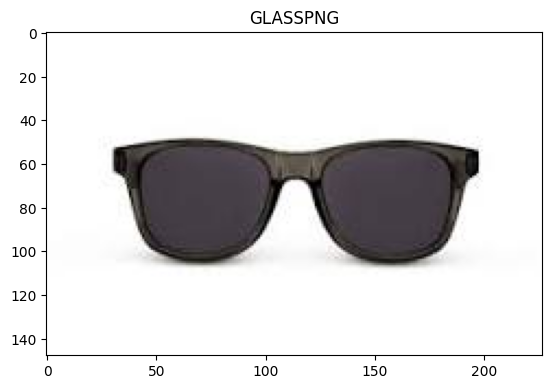

In [5]:
glasspng=cv2.imread("C:\\Users\\priya\\Downloads\\glass.jpg",-1)
plt.imshow(glasspng[:,:,::-1]);plt.title("GLASSPNG")

BGR shape: (148, 227, 3)
Alpha shape: (148, 227)


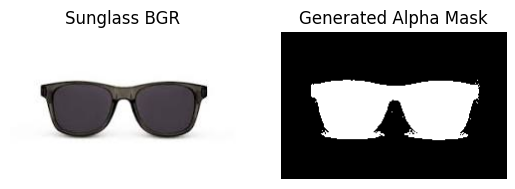

In [7]:
import cv2
import matplotlib.pyplot as plt
glasspng = cv2.imread("C:\\Users\\priya\\Downloads\\glass.jpg")
b, g, r = cv2.split(glasspng)
glass_bgr = cv2.merge((b, g, r))
gray = cv2.cvtColor(glasspng, cv2.COLOR_BGR2GRAY)

_, glass_alpha = cv2.threshold(gray, 240, 255, cv2.THRESH_BINARY_INV)

print("BGR shape:", glass_bgr.shape)
print("Alpha shape:", glass_alpha.shape)


plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(glass_bgr, cv2.COLOR_BGR2RGB))
plt.title("Sunglass BGR")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(glass_alpha, cmap="gray")
plt.title("Generated Alpha Mask")
plt.axis("off")

plt.show()

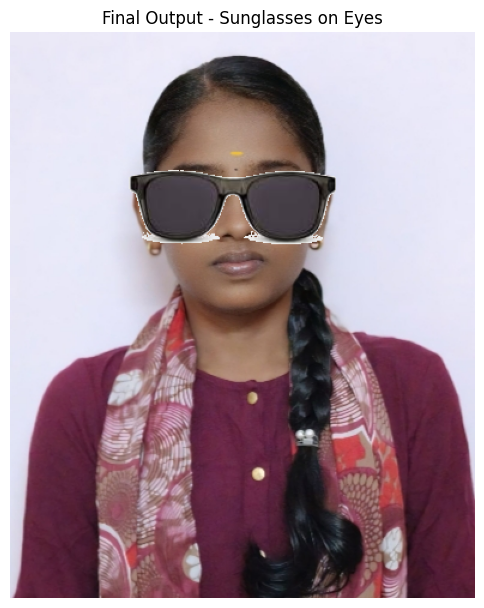

In [21]:
# Get face dimensions
face_h, face_w = faceimage.shape[:2]

# Use the sunglasses image you already loaded
glassBGR = glasspng.copy()

# Resize glasses
glass_w = int(face_w * 0.60)
glass_h = int(glass_w * glassBGR.shape[0] / glassBGR.shape[1])

glassBGR = cv2.resize(glassBGR, (glass_w, glass_h))

# Create mask
glass_gray = cv2.cvtColor(glassBGR, cv2.COLOR_BGR2GRAY)
_, glassMask = cv2.threshold(glass_gray, 240, 255, cv2.THRESH_BINARY_INV)

glassMask = cv2.merge([glassMask, glassMask, glassMask])
glassMask = glassMask / 255.0

# Position of glasses
x1 = int(face_w * 0.18)
y1 = int(face_h * 0.14)

x2 = x1 + glass_w
y2 = y1 + glass_h

# Copy face image
faceWithGlasses = faceimage.copy()

# Extract ROI
eyeROI = faceWithGlasses[y1:y2, x1:x2]

# Ensure dimensions match
glassBGR = cv2.resize(glassBGR, (eyeROI.shape[1], eyeROI.shape[0]))
glassMask = cv2.resize(glassMask, (eyeROI.shape[1], eyeROI.shape[0]))

# Convert to float
eyeROI_f = eyeROI.astype(np.float32)
glassBGR_f = glassBGR.astype(np.float32)
glassMask_f = glassMask.astype(np.float32)

# Blend
maskedEye = cv2.multiply(eyeROI_f, (1 - glassMask_f))
maskedGlass = cv2.multiply(glassBGR_f, glassMask_f)

eyeFinal = cv2.add(maskedEye, maskedGlass)
eyeFinal = np.clip(eyeFinal, 0, 255).astype(np.uint8)

# Put result back
faceWithGlasses[y1:y2, x1:x2] = eyeFinal

# Display
plt.figure(figsize=(6,8))
plt.imshow(cv2.cvtColor(faceWithGlasses, cv2.COLOR_BGR2RGB))
plt.title("Final Output - Sunglasses on Eyes")
plt.axis("off")
plt.show()

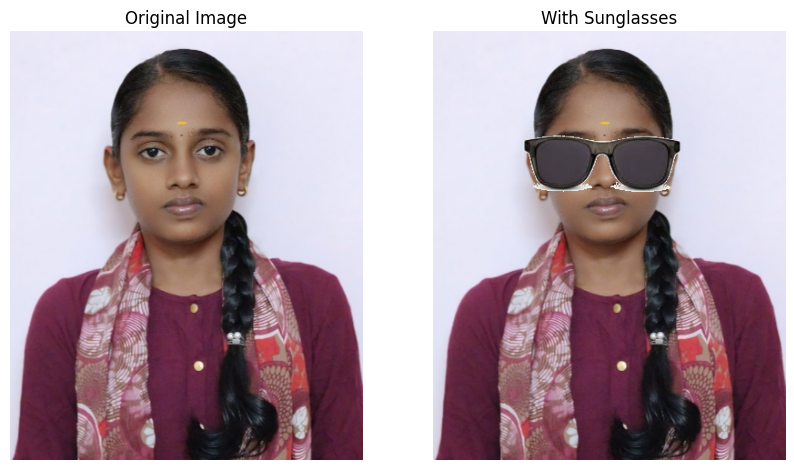

In [24]:
# Copy face image
faceWithGlassesArithmetic = faceimage.copy()

# Face dimensions
face_h, face_w, _ = faceWithGlassesArithmetic.shape

# Use the glasses image loaded earlier
glassBGR = glasspng.copy()

# Resize glasses
glass_w = int(face_w * 0.60)
glass_h = int(glass_w * glassBGR.shape[0] / glassBGR.shape[1])

glass_resized = cv2.resize(glassBGR, (glass_w, glass_h))

# Create mask
glass_gray = cv2.cvtColor(glass_resized, cv2.COLOR_BGR2GRAY)
_, glassMask = cv2.threshold(glass_gray, 240, 255, cv2.THRESH_BINARY_INV)

glassMask = cv2.merge([glassMask, glassMask, glassMask]) / 255.0

# Position glasses
x1 = int(face_w * 0.18)
y1 = int(face_h * 0.14)

x2 = x1 + glass_w
y2 = y1 + glass_h

# Extract ROI
eyeROI = faceWithGlassesArithmetic[y1:y2, x1:x2]

# Resize again if needed to match ROI size exactly
glass_resized = cv2.resize(glass_resized, (eyeROI.shape[1], eyeROI.shape[0]))
glassMask = cv2.resize(glassMask, (eyeROI.shape[1], eyeROI.shape[0]))

# Convert to float
eyeROI_f = eyeROI.astype(np.float32)
glass_f = glass_resized.astype(np.float32)
glassMask_f = glassMask.astype(np.float32)

# Blend
maskedEye = cv2.multiply(eyeROI_f, 1 - glassMask_f)
maskedGlass = cv2.multiply(glass_f, glassMask_f)

eyeFinal = cv2.add(maskedEye, maskedGlass)
eyeFinal = np.clip(eyeFinal, 0, 255).astype(np.uint8)

# Put result back
faceWithGlassesArithmetic[y1:y2, x1:x2] = eyeFinal

# Display result
plt.figure(figsize=(10, 10))

plt.subplot(121)
plt.imshow(cv2.cvtColor(faceimage, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(122)
plt.imshow(cv2.cvtColor(faceWithGlassesArithmetic, cv2.COLOR_BGR2RGB))
plt.title("With Sunglasses")
plt.axis("off")

plt.show()